# Models From an Action

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/dev/examples/03-building-models/models_from_an_action.ipynb)

Every model in `CosmoFit.cosmology.models` encodes the *result* of a
derivation somebody did by hand: an `E(z)` transcribed from a paper.
[`custom_models.ipynb`](custom_models.ipynb) lowers the barrier to
adding one, but not the work — it still wants `E(z)`.

This notebook takes the input instead. Give `CosmoFit.theory` a
gravitational **action** on an FLRW metric, and it derives `E(z)`
itself: reduces the action to a point-like Lagrangian, varies the
lapse to get the Friedmann constraint, solves it, and hands back an
ordinary `Cosmology` subclass that every dataset, likelihood, sampler
and plot already knows how to use.

Along the way we check it against models this library already had,
fit a modified-gravity theory to real data, and look at the three
places it refuses to answer rather than approximate.

Scalar fields get their own notebook:
[`scalar_field_models.ipynb`](scalar_field_models.ipynb).

## Setup\n\nThe symbolic machinery needs `sympy`, an optional extra.

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e ".[theory]"

    # The editable install runs in a subprocess, so this already-running
    # kernel does not see the .pth it writes -- and `import CosmoFit`
    # would resolve to the bare checkout directory instead (same name,
    # and /content is on sys.path). Point sys.path at src/ directly.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e \".[theory]\" from the repository root).")

Not running in Colab -- assuming CosmoFit is already installed (pip install -e ".[theory]" from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy

from CosmoFit import Fitter
from CosmoFit.cosmology.models import LCDM, FQExponential
from CosmoFit.theory import Action

sympy.init_printing()
plt.rcParams["figure.dpi"] = 110

## 1. ΛCDM, written as an action

The Einstein–Hilbert action with a cosmological constant is
`R - 2Λ`. Nothing else is supplied: no expansion history, no
Friedmann equation.

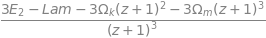

In [3]:
lcdm_action = Action("R - 2*Lam", closure="Lam")

constraint, E2, z = lcdm_action.constraint()
constraint

That expression vanishes on-shell — it *is* the Friedmann equation,
derived rather than typed in. Rearranged, `E2 = Omega_m(1+z)³ +
Omega_k(1+z)² + Lam/3`.

**Why the lapse matters.** FLRW is written here with an explicit
lapse `N(t)`,

$$ds^2 = -N(t)^2\,dt^2 + a(t)^2\,d\Sigma_k^2,$$

and it is carried through the whole reduction, set to 1 only at the
very end. `N` is a non-dynamical gauge degree of freedom, so varying
it produces a **constraint** rather than an evolution equation — and
that constraint is the Friedmann equation. Writing `N = 1` from the
start loses it altogether.

### The closure condition

`closure="Lam"` names the one parameter fixed by requiring
`E(0) = 1` — which is just `H(0) = H0`, true by definition of `H0`.
Nothing in the action says `Λ = 3Ω_de0`; it falls out of that
condition.

In [4]:
LCDMfromAction = lcdm_action.build("LCDM_from_action")

print(f"{'Omega_m':>8s} {'Omega_k':>8s} {'closure Lam':>13s} {'3*Omega_de0':>13s}")
for Om, Ok in [(0.315, 0.0), (0.25, 0.05), (0.40, -0.02)]:
    derived = LCDMfromAction(LCDMfromAction.PARAMS_CLASS(H0=67.4, Omega_m=Om, Omega_k=Ok))
    direct = LCDM(LCDM.PARAMS_CLASS(H0=67.4, Omega_m=Om, Omega_k=Ok))
    print(f"{Om:8.3f} {Ok:8.2f} {derived.closure_value():13.9f} "
          f"{3 * direct.Omega_de0:13.9f}")

 Omega_m  Omega_k   closure Lam   3*Omega_de0
   0.315     0.00   2.055000000   2.055000000
   0.250     0.05   2.100000000   2.100000000
   0.400    -0.02   1.860000000   1.860000000


### Does it actually reproduce `LCDM`?

In [5]:
zz = np.array([0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 20.0])

derived = LCDMfromAction(LCDMfromAction.PARAMS_CLASS(H0=67.4, Omega_m=0.315))
direct = LCDM(LCDM.PARAMS_CLASS(H0=67.4, Omega_m=0.315))

print(f"max |E_action - E_LCDM|      = {np.max(np.abs(derived.E(zz) - direct.E(zz))):.3e}")
print(f"max |dEdz_action - dEdz_LCDM| = {np.max(np.abs(derived.dEdz(zz) - direct.dEdz(zz))):.3e}")
print("\n(both at the level of double-precision round-off)")

max |E_action - E_LCDM|      = 2.220e-16
max |dEdz_action - dEdz_LCDM| = 4.441e-16
(both at the level of double-precision round-off)


## 2. The demanding case: exponential f(Q)

`f(Q)` is symmetric-teleparallel gravity — the non-metricity scalar
`Q` replaces the Ricci scalar. The exponential model of
Anagnostopoulos, Basilakos & Saridakis is

$$f(Q) = Q\,e^{\lambda Q_0/Q},\qquad Q = 6H^2 .$$

This library already carries it as `FQExponential`, whose Friedmann
equation is **transcendental** and is inverted there with a Lambert
`W`. So the derivation has two things to get right: the equation, and
which branch of it.

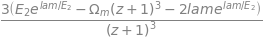

In [6]:
fq_action = Action(
    "Q * exp(lam * Q0 / Q)",
    geometry="symmetric",
    params={"lam": {"default": 0.3}},
    closure="lam",
    growth="quasi_static",       # mu = 1/f_Q, for growth data
)

constraint, E2, z = fq_action.constraint()
constraint

In [7]:
# What FQExponential's docstring states, from the paper:
lam, Omega_m = sympy.Symbol("lam"), sympy.Symbol("Omega_m")
published = (E2 - 2 * lam) * sympy.exp(lam / E2) - Omega_m * (1 + z) ** 3

ratio = sympy.simplify(sympy.cancel(constraint / published))
print("derived / published =", ratio)
print("\nfree symbols in the ratio:", ratio.free_symbols)
print("A constraint is only defined up to a non-vanishing factor, so a")
print("ratio with no E2 or Omega_m in it means the two have the same zero set.")

derived / published = 3/(z**3 + 3*z**2 + 3*z + 1)
free symbols in the ratio: {z}
A constraint is only defined up to a non-vanishing factor, so a
ratio with no E2 or Omega_m in it means the two have the same zero set.


In [8]:
FQfromAction = fq_action.build("FQ_from_action")

print(f"{'Omega_m':>8s} {'lam (derived)':>14s} {'lam (Lambert W)':>16s} "
      f"{'max dE':>10s} {'max dmu':>10s}")
for Om in (0.25, 0.30, 0.35):
    d = FQfromAction(FQfromAction.PARAMS_CLASS(H0=68.0, Omega_m=Om))
    r = FQExponential(FQExponential.PARAMS_CLASS(H0=68.0, Omega_m=Om))
    a = 1.0 / (1.0 + zz)
    print(f"{Om:8.2f} {d.closure_value():14.10f} {r._lam:16.10f} "
          f"{np.max(np.abs(d.E(zz) - r.E(zz))):10.2e} "
          f"{np.max(np.abs(d.mu(a) - r.mu(a))):10.2e}")

 Omega_m  lam (derived)  lam (Lambert W)     max dE    max dmu
    0.25   0.4176782377     0.4176782377   8.88e-16   2.22e-16
    0.30   0.3993907117     0.3993907117   1.78e-15   2.22e-16
    0.35   0.3803683248     0.3803683248   7.11e-15   2.22e-16


`mu` there is the growth coupling `G_eff/G_N = 1/f_Q`, derived by
differentiating the action rather than typed in. It is **opt-in**
(`growth="quasi_static"`) because it is a statement about
perturbations, which a background action does not by itself
determine.

## 3. Fitting a new model: power-law f(T)

`f(T)` is teleparallel gravity — torsion instead of curvature. The
Bengochea & Ferraro model is

$$f(T) = T + \alpha(-T)^{b},$$

with `b = 0` collapsing the correction to a constant, i.e. exactly a
cosmological constant. This one is *not* in the library, so from here
on there is nothing to check against — only data.

In [9]:
PowerLawFT = Action(
    "T + A0*(-T)**b",
    geometry="teleparallel",
    params={
        "A0": {"default": -4.2, "bounds": (-30.0, 0.0)},
        "b": {"default": 0.0, "bounds": (-2.0, 0.9), "label": r"$b$"},
    },
    closure="A0",
).build("PowerLawFT")

# Sanity: b = 0 must be LCDM exactly.
b0 = PowerLawFT(PowerLawFT.PARAMS_CLASS(H0=70.0, Omega_m=0.3, b=0.0))
ref = LCDM(LCDM.PARAMS_CLASS(H0=70.0, Omega_m=0.3))
print(f"b = 0 vs LCDM: max |dE| = {np.max(np.abs(b0.E(zz) - ref.E(zz))):.3e}")
print(f"closure A0 = {b0.closure_value():.6f}   (-6*Omega_de0 = {-6 * ref.Omega_de0:.6f})")

b = 0 vs LCDM: max |dE| = 7.105e-15
closure A0 = -4.200000   (-6*Omega_de0 = -4.200000)


### What `b` does to the expansion history

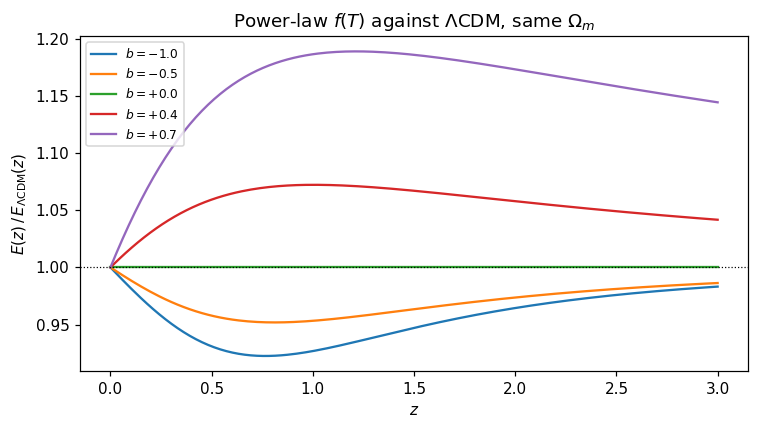

In [10]:
zplot = np.linspace(0.0, 3.0, 200)
fig, ax = plt.subplots(figsize=(7, 4))

for b in (-1.0, -0.5, 0.0, 0.4, 0.7):
    m = PowerLawFT(PowerLawFT.PARAMS_CLASS(H0=70.0, Omega_m=0.3, b=b))
    ax.plot(zplot, m.E(zplot) / ref.E(zplot), label=f"$b = {b:+.1f}$")

ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("$z$")
ax.set_ylabel(r"$E(z)\,/\,E_{\Lambda\rm CDM}(z)$")
ax.set_title(r"Power-law $f(T)$ against $\Lambda$CDM, same $\Omega_m$")
ax.legend(fontsize=8)
fig.tight_layout()

### A real fit

Cosmic chronometers + DESI BAO, with `r_d` free. `b` is the departure
from ΛCDM, so the question is whether the data ask for one.

In [11]:
fit = Fitter(
    model=PowerLawFT,
    datasets=["cc", "desi"],
    free_params=["H0", "Omega_m", "b", "rd"],
    initial={"H0": 70.0, "Omega_m": 0.3, "b": 0.0, "rd": 147.0},
)

best = fit.best_fit(restarts=3, seed=0)
for name, value in zip(fit.free_params, best.x):
    print(f"  {name:8s} = {value: .4f}")
print(f"\n  chi2 = {best.fun:.3f}")

  H0       =  70.3188
  Omega_m  =  0.2939
  b        = -0.0364
  rd       =  145.4352
  chi2 = 25.630


In [12]:
reference = Fitter(
    model=LCDM,
    datasets=["cc", "desi"],
    free_params=["H0", "Omega_m", "rd"],
    initial={"H0": 70.0, "Omega_m": 0.3, "rd": 147.0},
).best_fit(restarts=3, seed=0)

print(f"LCDM        chi2 = {reference.fun:.3f}  (3 parameters)")
print(f"PowerLawFT  chi2 = {best.fun:.3f}  (4 parameters)")
print(f"\ndelta chi2 = {reference.fun - best.fun:+.3f} for one extra parameter")

LCDM        chi2 = 25.646  (3 parameters)
PowerLawFT  chi2 = 25.630  (4 parameters)
delta chi2 = +0.016 for one extra parameter


One extra parameter buys essentially nothing, which is what
published `f(T)` constraints from background data say. Now the
posterior, to see *how well* `b` is pinned rather than just where its
best fit sits.

In [13]:
fit.run_mcmc(nwalkers=32, nsteps=3000, burnin=600, seed=0, progress=True)
print(fit.result)

  0%|          | 0/3000 [00:00<?, ?it/s]


  0%|          | 2/3000 [00:00<02:49, 17.69it/s]


  0%|          | 4/3000 [00:00<02:56, 17.00it/s]


  0%|          | 6/3000 [00:00<02:50, 17.57it/s]


  0%|          | 8/3000 [00:00<02:43, 18.25it/s]


...

100%|█████████▉| 2997/3000 [02:51<00:00, 15.29it/s]


100%|█████████▉| 2999/3000 [02:51<00:00, 16.08it/s]


100%|██████████| 3000/3000 [02:51<00:00, 17.52it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 48;
tau: [49.63535991 59.36037284 77.77055619 48.62967826]


FitResult(model=PowerLawFT, datasets=['cc', 'desi'], free_params=['H0', 'Omega_m', 'b', 'rd'])
  BestFitResult(H0=70.3188, Omega_m=0.293883, b=-0.0364396, rd=145.435, chi2=25.6299, AIC=33.63, BIC=40.77)
  MCMCResult(32 walkers x 3000 steps, burnin=600, NOT converged, acceptance=0.54)
  H0 = 69.9741 (+3.7/-3.5)
  Omega_m = 0.29257 (+0.015/-0.016)
  b = -0.0638813 (+0.28/-0.32)
  rd = 146.262 (+6.7/-6.4)


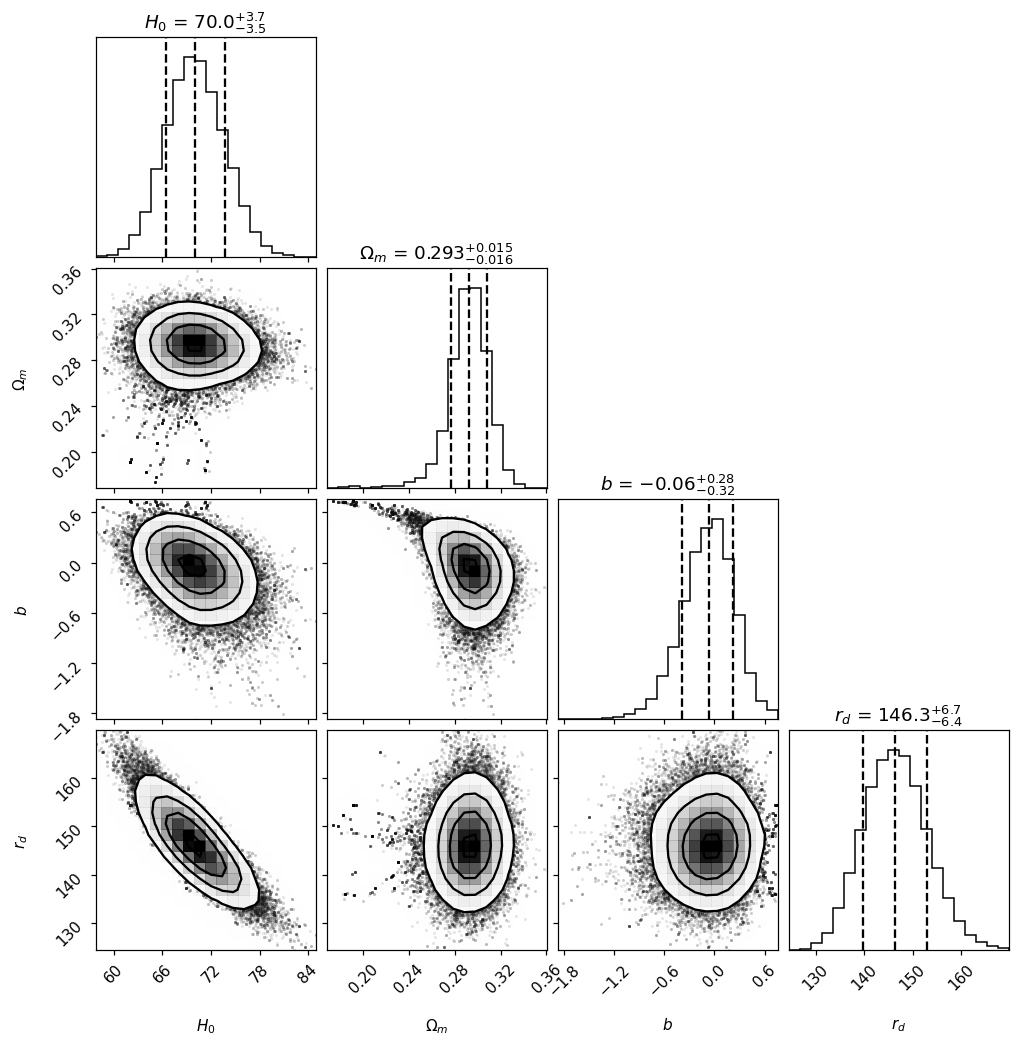

In [14]:
fit.plots.corner();

## 4. What it refuses to do

Three refusals, all of them cases where an answer could be produced
that looks fine and is wrong.

In [15]:
def show(label, thunk):
    try:
        thunk()
        print(f"{label}: NO ERROR")
    except Exception as exc:
        print(f"{label}:\n    {type(exc).__name__}: {exc}\n")


show(
    "An action nobody normalized",
    lambda: Action("R - 2*Lam", params={"Lam": {"default": 1.0}}).build("Y"),
)

show(
    "quasi-static growth in the metric sector",
    lambda: Action("R - 2*Lam", closure="Lam", growth="quasi_static").build("Z"),
)

An action nobody normalized:
    ValueError: E(0) = 0.795822, not 1: this action does not satisfy H(0) = H0 at its default parameters. Every distance it predicts would be wrong by that factor. Pass closure=<parameter name> to name the parameter fixed by that condition -- in Lambda-CDM, 'R - 2*Lam' with closure='Lam' is what makes Lam = 3 (1 - Omega_m - Omega_k).
quasi-static growth in the metric sector:
    NotImplementedError: growth='quasi_static' is implemented for the teleparallel and symmetric-teleparallel sectors, where mu = 1/f' is a settled sub-horizon result. In the metric sector it is f(R) gravity, whose mu is scale-dependent -- a Compton wavelength enters -- so a scale-free answer would be wrong rather than approximate. FRHuSawicki carries the standard f(R) mu(a, k) if that is what you need.


Taking those in turn:

**An unnormalized action** predicts every distance wrong by a
constant factor while looking entirely healthy — no fit would fail,
the numbers would just be wrong. Hence `closure=`.

**`mu = 1/f'`** is the sub-horizon quasi-static result for the
teleparallel sectors. In the metric sector it is `f(R)` gravity,
whose `mu` is scale-dependent — a Compton wavelength enters — so a
scale-free answer would be wrong rather than approximate.

### Sign conventions

The three geometry scalars carry different signs across the
literature, and picking one wrongly inverts every modification built
on it with nothing downstream complaining. They are fixed here by
requiring that an undeformed `f` reproduce General Relativity
exactly, and the test suite asserts that in all three sectors rather
than trusting the convention.

In [16]:
from CosmoFit.theory import GEOMETRIES, Minisuperspace
from CosmoFit.theory.minisuperspace import (
    GEOMETRY_SCALAR, fluid_lagrangian, friedmann_constraint,
    gravity_lagrangian, reduce_order,
)

Om = sympy.Symbol("Omega_m", positive=True)

for geometry in GEOMETRIES:
    ms = Minisuperspace()
    scalar = sympy.Symbol(GEOMETRY_SCALAR[geometry])
    L = gravity_lagrangian(ms, geometry, scalar, scalar)
    L += fluid_lagrangian(ms, {0: 3 * Om})
    C = friedmann_constraint(reduce_order(L, ms), ms)

    H = sympy.diff(ms.a, ms.t) / ms.a
    if geometry == "metric":
        target = 3 * (H**2 + ms.k / ms.a**2) - 3 * Om / ms.a**3
    else:
        target = 3 * H**2 - 3 * Om / ms.a**3
        C = C.subs(ms.k, 0)

    ratio = sympy.simplify(sympy.cancel(C / (ms.a**3 * target)))
    print(f"  f = {GEOMETRY_SCALAR[geometry]:>1s}  ({geometry:>14s}):  "
          f"constraint / Friedmann = {ratio}")

  f = R  (        metric):  constraint / Friedmann = 1
  f = T  (  teleparallel):  constraint / Friedmann = 1


  f = Q  (     symmetric):  constraint / Friedmann = 1


## 5. A general `f(R)`, which needs a different reduction

One case is missing from the list above, and it is the one you were
probably going to type first. The reduction removes the `ä` in the
Einstein–Hilbert term by integrating by parts, which is legitimate
only when the Lagrangian is **linear** in `ä`. For a general `f(R)`
it is not — the discarded piece would not be a total derivative, and
dropping it returns a different theory.

The way round is to stop treating `R` as shorthand for a combination
of `a` and its derivatives, and make it an *independent* variable
held to that combination by a Lagrange multiplier. Substituting the
multiplier back gives

$$L = \tfrac{1}{2} N a^3 \left[ f(R) - f'(R)\,R + f'(R)\,R_{\rm geom} \right],$$

which is linear in `ä` again — because `R_geom` is, and it now
appears only multiplied by `f'(R)`. The cost is one extra dynamical
variable, which is the theory's fourth order made visible.

`Action` detects this and routes there on its own.

In [17]:
starobinsky = Action(
    "R - 2*Lam + alpha_fr*R**2",
    params={
        "Lam": {"default": 2.1, "bounds": (0.0, 6.0)},
        "alpha_fr": {"default": 1e-3, "bounds": (1e-6, 1.0)},
    },
)

print("fourth order:", starobinsky.is_fourth_order)
print("linear in R: ", Action("R - 2*Lam", closure="Lam").is_fourth_order)

Starobinsky = starobinsky.build("Starobinsky")
print("\nparameters:", sorted(Starobinsky.EXTRA_PARAMS))

fourth order: True
linear in R:  False


parameters: ['Lam', 'R_0', 'alpha_fr']


`R_0` is new, and it is not bookkeeping: a fourth-order theory has
an initial condition General Relativity does not — the Ricci scalar
today, which is to say today's deceleration. Its default is the
ΛCDM value at `Omega_m = 0.3`.

Note also that there is no `closure` here. The history is integrated
outwards from `a = 1` with `H = 1` imposed there, so `E(0) = 1`
holds by construction and the freedom a closure would have fixed is
carried by `R_0` instead.

In [18]:
R0 = 6 * (2 - 1.5 * 0.3)      # the LCDM value, in units of H0^2

print(f"{'alpha':>9s} {'E(0)':>14s} {'max|E/E_LCDM-1|':>17s} {'residual':>11s}")
for alpha in (1e-1, 1e-3, 1e-5):
    m = Starobinsky(Starobinsky.PARAMS_CLASS(
        H0=70.0, Omega_m=0.3, Lam=2.1, alpha_fr=alpha, R_0=R0))
    departure = np.max(np.abs(m.E(zz[:6]) / ref.E(zz[:6]) - 1))
    print(f"{alpha:9.0e} {float(m.E(0.0)):14.10f} {departure:17.3e} "
          f"{m.history(zz[:6]).drift:11.2e}")

    alpha           E(0)   max|E/E_LCDM-1|    residual
    1e-01   1.0000000000         6.449e-01    4.44e-15
    1e-03   1.0000000000         1.826e-01    1.62e-15
    1e-05   1.0000000000         4.172e-03    2.13e-15


The correction switches off smoothly as `alpha → 0`, which is the
General Relativity limit.

The last column is the accuracy check, and it is a different one
from the scalar-field case. There the Friedmann constraint is a
first integral the integration never imposes, so its drift measures
the error. Here the constraint is one of the two equations that
*define* the right-hand side, so its residual is zero by
construction and measures nothing. What is left over is the **third**
equation of motion — from varying `a` — which follows from the other
two by the Bianchi identity. It holds on an exact solution and
drifts on an approximate one, and that is what is reported.

## Where to go next

- [`scalar_field_models.ipynb`](scalar_field_models.ipynb) — actions
  with dynamical fields (quintessence, k-essence), where the history
  has to be integrated rather than solved.
- [`custom_models.ipynb`](custom_models.ipynb) — the lighter route,
  when you already have `E(z)`.
- [`../04-inference/evidence_and_model_selection.ipynb`](../04-inference/evidence_and_model_selection.ipynb)
  — deciding whether a new model's improvement is real.

`Action.constraint()` and `Action.field_equations()` return the
derivation itself, if that is what you came for rather than the fit.